# Data Analysis

In [1]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_doymus = pd.read_excel("R515B_Ozellikler/R515B_Doymus_Ozellikleri.xlsx")
df_kizgin = pd.read_excel("R515B_Ozellikler/R515B_Kizgin_Buhar.xlsx")

## Doymuş Buhar Özellikleri (R515B)
Bu veri seti, R515B soğutucu akışkanının **doymuş** durumundaki termodinamik özelliklerini içermektedir.

In [3]:
df_doymus.head()

,T(girdi),P(çıktı),v sıvı (çıktı),v buhar (çıktı),h sıvı (çıktı),h buhar (çıktı),s sıvı (çıktı),s buhar (çıktı)
0,C,kPa,m3/kg,m3/kg,Kj/kg,kj/kg,kj/kg K,kj/kgK
1,-30,61.221,0.000745,0.27264,2.7282,198.2,0.04464,0.84856
2,-29,64.235,0.000746,0.26063,3.9422,198.89,0.049614,0.84809
3,-28,67.367,0.000748,0.24925,5.1587,199.58,0.054576,0.84764
4,-27,70.62,0.000749,0.23847,6.3775,200.27,0.059528,0.84721


### Veri Seti Boyutu
Veri setindeki satır (gözlem) ve sütun (değişken) sayısını kontrol ediyoruz.

In [4]:
df_doymus.shape

(137, 8)

### Veri Tipleri ve Genel Bilgi
Her bir sütunun veri tipi, boş olmayan değer sayısı ve bellek kullanımı hakkında bilgi ediniyoruz.

In [5]:
df_doymus.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137 entries, 0 to 136
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   T(girdi)         137 non-null    object
 1   P(çıktı)         137 non-null    object
 2   v sıvı (çıktı)   137 non-null    object
 3   v buhar (çıktı)  137 non-null    object
 4   h sıvı (çıktı)   137 non-null    object
 5   h buhar (çıktı)  137 non-null    object
 6   s sıvı (çıktı)   137 non-null    object
 7   s buhar (çıktı)  137 non-null    object
dtypes: object(8)
memory usage: 8.7+ KB


### Sütun İsimleri
Veri setindeki tüm sütun isimlerini listeliyoruz.

In [6]:
df_doymus.columns.tolist()

['T(girdi)',
 'P(çıktı)',
 'v sıvı (çıktı)',
 'v buhar (çıktı)',
 'h sıvı (çıktı)',
 'h buhar (çıktı)',
 's sıvı (çıktı)',
 's buhar (çıktı)']

### İstatistiksel Özet
Sayısal sütunlara ait temel istatistiksel bilgiler (ortalama, standart sapma, min, max, çeyrekler).

In [7]:
df_doymus.describe()

,T(girdi),P(çıktı),v sıvı (çıktı),v buhar (çıktı),h sıvı (çıktı),h buhar (çıktı),s sıvı (çıktı),s buhar (çıktı)
count,137,137,137,137,137,137.00,137,137.00000
unique,137,137,137,137,137,136.00,137,131.00000
top,C,kPa,m3/kg,m3/kg,Kj/kg,257.54,kj/kg K,0.84274
freq,1,1,1,1,1,2.00,1,2.00000


### Eksik Veri Analizi
Her sütundaki eksik (null/NaN) değer sayısını kontrol ediyoruz.

In [8]:
df_doymus.isnull().sum()

T(girdi)           0
P(çıktı)           0
v sıvı (çıktı)     0
v buhar (çıktı)    0
h sıvı (çıktı)     0
h buhar (çıktı)    0
s sıvı (çıktı)     0
s buhar (çıktı)    0
dtype: int64

### Eksik Veri Görselleştirmesi
`missingno` kütüphanesi ile eksik verilerin dağılımını görsel olarak inceliyoruz.

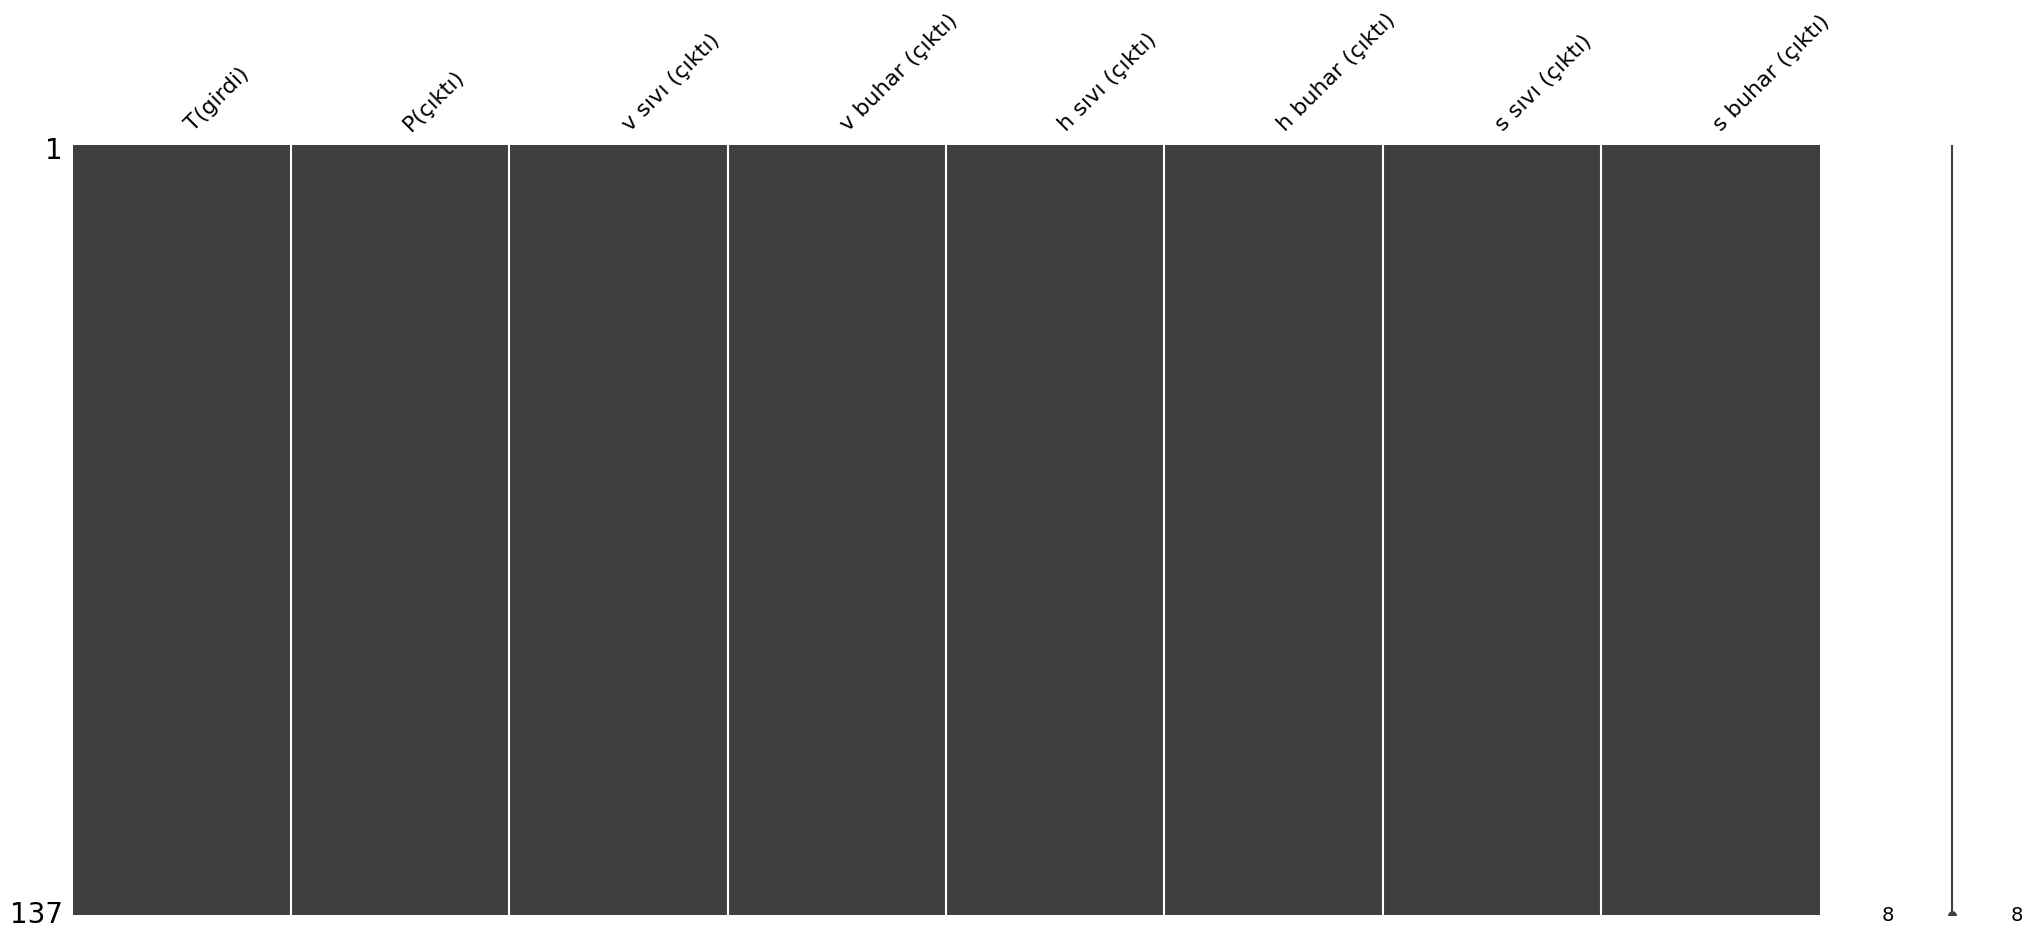

In [9]:
msno.matrix(df_doymus);

### Tekrarlayan (Duplicate) Veri Kontrolü
Veri setinde tamamen aynı olan satır sayısını kontrol ediyoruz.

In [10]:
df_doymus.duplicated().sum()

np.int64(0)

### Korelasyon Matrisi
Sayısal değişkenler arasındaki doğrusal ilişkiyi gösteren korelasyon matrisi.

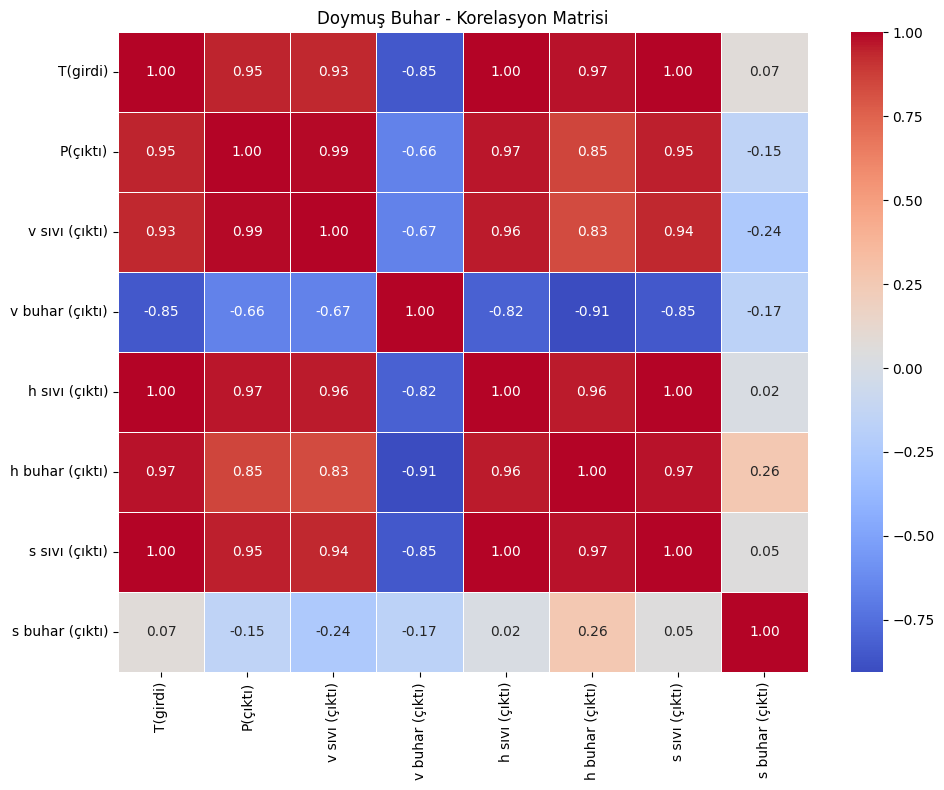

In [11]:
df_doymus_numeric = df_doymus.apply(lambda col: pd.to_numeric(col.astype(str).str.replace(",", "."), errors="coerce"))

plt.figure(figsize=(10, 8))
sns.heatmap(df_doymus_numeric.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Doymuş Buhar - Korelasyon Matrisi")
plt.tight_layout()
plt.show()

### Son Satırlar
Veri setinin son 5 satırını inceliyoruz.

In [12]:
df_doymus.tail()

,T(girdi),P(çıktı),v sıvı (çıktı),v buhar (çıktı),h sıvı (çıktı),h buhar (çıktı),s sıvı (çıktı),s buhar (çıktı)
132,101,3089.7,0.001305,0.004051,196.85,259.48,0.66274,0.83013
133,102,3151.2,0.001329,0.003877,199.31,258.6,0.66909,0.82714
134,103,3213.8,0.001356,0.003698,201.89,257.54,0.67574,0.82369
135,104,3277.5,0.001388,0.003514,204.63,256.23,0.6828,0.81961
136,105,3342.5,0.001426,0.00332,207.61,254.59,0.69043,0.81468


## Kızgın Buhar Özellikleri (R515B)
Bu veri seti, R515B soğutucu akışkanının **kızgın (süper ısıtılmış)** buhar durumundaki termodinamik özelliklerini içermektedir.

In [13]:
df_kizgin.head()

,T (girdi),P (girdi),v (çıktı),h (çıktı),s (çıktı),state
0,C,kPa,m3/kg,kJ/kg,kJ/kg K,NaN
1,-30,50,0.33575,198.55,0.86391,Superheated
2,-25,50,0.34327,202.45,0.87981,Superheated
3,-20,50,0.35075,206.4,0.89557,Superheated
4,-15,50,0.35821,210.4,0.9112,Superheated


### Veri Seti Boyutu
Veri setindeki satır (gözlem) ve sütun (değişken) sayısını kontrol ediyoruz.

In [14]:
df_kizgin.shape

(579, 6)

### Veri Tipleri ve Genel Bilgi
Her bir sütunun veri tipi, boş olmayan değer sayısı ve bellek kullanımı hakkında bilgi ediniyoruz.

In [15]:
df_kizgin.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 579 entries, 0 to 578
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   T (girdi)  579 non-null    object
 1   P (girdi)  579 non-null    object
 2   v (çıktı)  579 non-null    object
 3   h (çıktı)  579 non-null    object
 4   s (çıktı)  579 non-null    object
 5   state      578 non-null    object
dtypes: object(6)
memory usage: 27.3+ KB


### Sütun İsimleri
Veri setindeki tüm sütun isimlerini listeliyoruz.

In [16]:
df_kizgin.columns.tolist()

['T (girdi)', 'P (girdi)', 'v (çıktı)', 'h (çıktı)', 's (çıktı)', 'state']

### İstatistiksel Özet
Sayısal sütunlara ait temel istatistiksel bilgiler (ortalama, standart sapma, min, max, çeyrekler).

In [17]:
df_kizgin.describe()

,T (girdi),P (girdi),v (çıktı),h (çıktı),s (çıktı),state
count,579,579,579.000000,579.00,579.00000,578
unique,29,66,578.000000,567.00,570.00000,1
top,105,50,0.010187,288.42,0.90032,Superheated
freq,65,28,2.000000,2.00,2.00000,578


### Eksik Veri Analizi
Her sütundaki eksik (null/NaN) değer sayısını kontrol ediyoruz.

In [18]:
df_kizgin.isnull().sum()

T (girdi)    0
P (girdi)    0
v (çıktı)    0
h (çıktı)    0
s (çıktı)    0
state        1
dtype: int64

### Eksik Veri Görselleştirmesi
`missingno` kütüphanesi ile eksik verilerin dağılımını görsel olarak inceliyoruz.

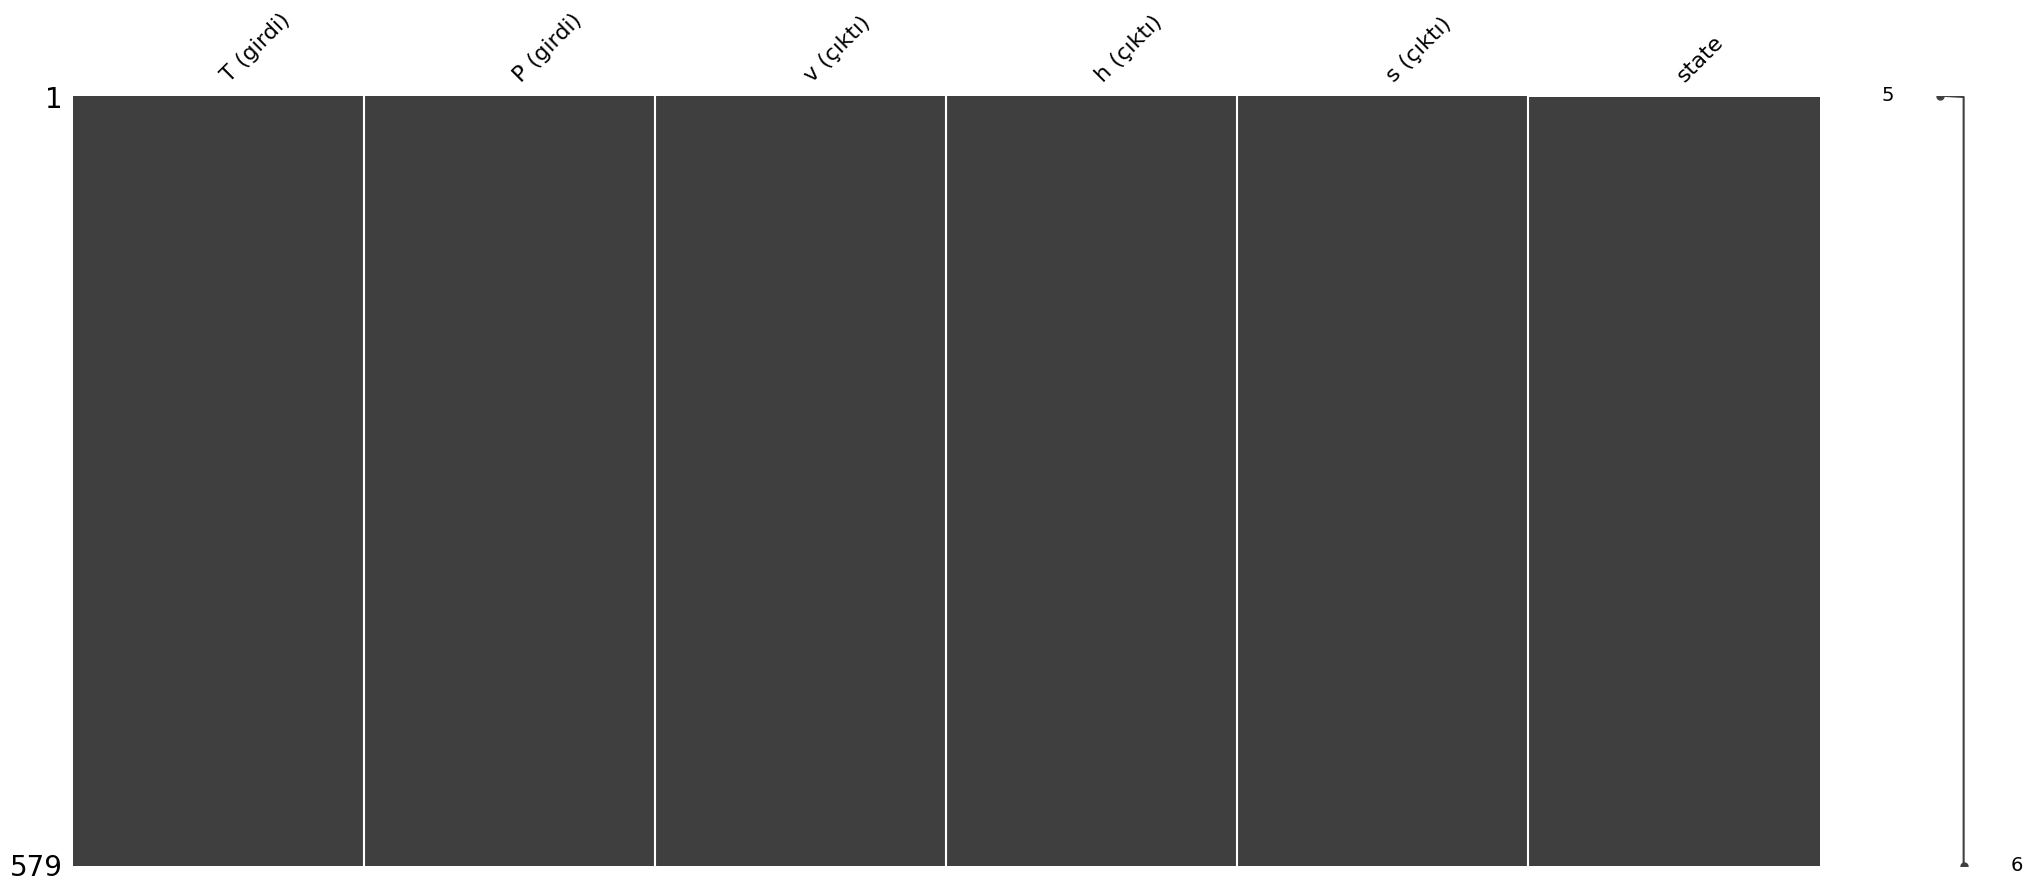

In [19]:
msno.matrix(df_kizgin);

### Tekrarlayan (Duplicate) Veri Kontrolü
Veri setinde tamamen aynı olan satır sayısını kontrol ediyoruz.

In [20]:
df_kizgin.duplicated().sum()

np.int64(0)

### Korelasyon Matrisi
Sayısal değişkenler arasındaki doğrusal ilişkiyi gösteren korelasyon matrisi.

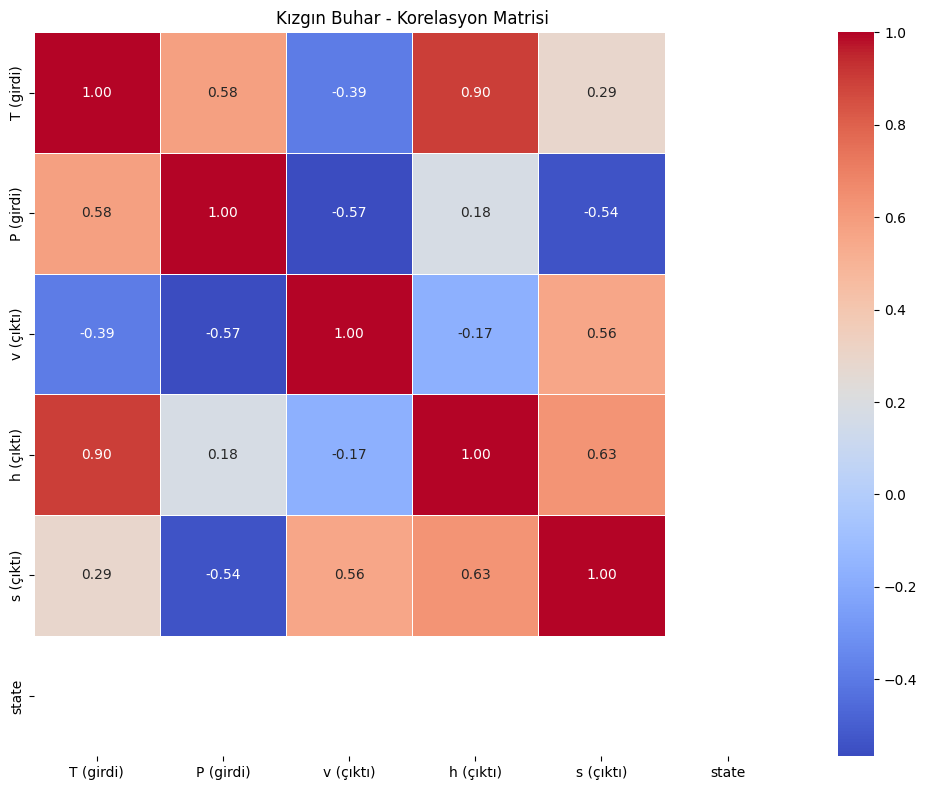

In [21]:
df_kizgin_numeric = df_kizgin.apply(lambda col: pd.to_numeric(col.astype(str).str.replace(",", "."), errors="coerce"))

plt.figure(figsize=(10, 8))
sns.heatmap(df_kizgin_numeric.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Kızgın Buhar - Korelasyon Matrisi")
plt.tight_layout()
plt.show()

### Son Satırlar
Veri setinin son 5 satırını inceliyoruz.

In [22]:
df_kizgin.tail()

,T (girdi),P (girdi),v (çıktı),h (çıktı),s (çıktı),state
574,105,3100,0.004612,270.44,0.85918,Superheated
575,105,3150,0.004393,268.31,0.85293,Superheated
576,105,3200,0.004163,265.87,0.84592,Superheated
577,105,3250,0.003916,262.97,0.83772,Superheated
578,105,3300,0.003632,259.25,0.8274,Superheated
